In [1]:
import geopandas as gpd
import random
from shapely.geometry import Point

In [2]:
gdf = gpd.read_file("../data/gis/mavfa-fs-3000_zone.shp")

# 2. Imposta CRS (se manca)
gdf = gdf.set_crs("EPSG:4326")

# (opzionale ma consigliato) lavora in metri
#gdf = gdf.to_crs("EPSG:3857")

In [3]:
gdf

,area_id,zone_name,cod_pro,origin,layer_id,lat,lon,geometry
0,SM,Repubblica di San Marino,99.0,Manual insert,3000.0,43.938325,12.463315,"POLYGON ((12.41168 43.93891, 12.41032 43.93991..."
1,VA,Città del Vaticano,58.0,Manual insert,3000.0,41.903445,12.453023,"POLYGON ((12.44658 41.90241, 12.44682 41.90224..."
2,5010,Napoli - 11,63.0,napoli,3000.0,40.847021,14.267001,"POLYGON ((14.2758 40.84482, 14.27442 40.84454,..."
3,10010041002,Varallo,2.0,CESPI,3000.0,45.820946,8.246350,"POLYGON ((8.16704 45.77608, 8.16682 45.7763, 8..."
4,10010041003,Balmuccia,2.0,CESPI,3000.0,45.772575,8.038943,"POLYGON ((8.06444 45.79512, 8.0646 45.79521, 8..."
...,...,...,...,...,...,...,...,...
2975,3049,Latino,58.0,roma,3000.0,41.875260,12.521160,"POLYGON ((12.52275 41.88904, 12.5228 41.88901,..."
2976,6020,Padova,15.0,milano,3000.0,45.504990,9.224978,"POLYGON ((9.23631 45.48613, 9.23473 45.48612, ..."
2977,6021,Buenos Aires - Venezia,15.0,milano,3000.0,45.477025,9.214489,"POLYGON ((9.21526 45.48645, 9.21597 45.4861, 9..."
2978,6040,Parco delle Abbazie,15.0,milano,3000.0,45.418270,9.197160,"POLYGON ((9.21048 45.39686, 9.21038 45.39684, ..."


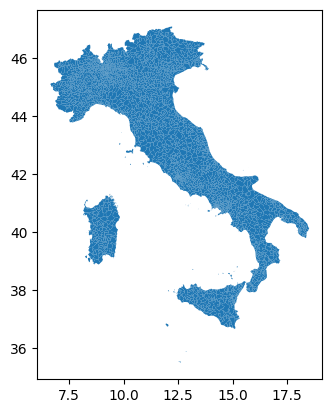

In [17]:
gdf.plot();

In [4]:
firenze_centro_storico = gdf[gdf.zone_name == 'Firenze Centro Storico']
#firenze_centro_storico = firenze_centro_storico.to_crs("EPSG:4326")
firenze_centro_storico

,area_id,zone_name,cod_pro,origin,layer_id,lat,lon,geometry
2657,1009006000,Firenze Centro Storico,48.0,citta_metro,3000.0,43.761575,11.233814,"POLYGON ((11.30134 43.76433, 11.30338 43.76379..."


In [7]:
gdf[gdf.area_id == '1009006000']

,area_id,zone_name,cod_pro,origin,layer_id,lat,lon,geometry
2657,1009006000,Firenze Centro Storico,48.0,citta_metro,3000.0,43.761575,11.233814,"POLYGON ((11.30134 43.76433, 11.30338 43.76379..."


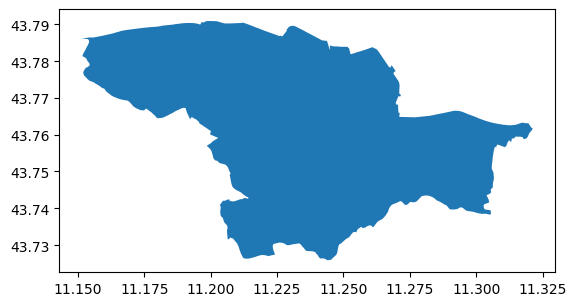

In [19]:
firenze_centro_storico.plot();

In [20]:
gdf[gdf.zone_name == 'Campo di Marte']

,area_id,zone_name,cod_pro,origin,layer_id,lat,lon,geometry
2659,1009006002,Campo di Marte,48.0,citta_metro,3000.0,43.789761,11.293229,"POLYGON ((11.28752 43.83132, 11.28753 43.83125..."


In [21]:

# 4. Funzione per punto casuale
def random_point_in_polygon(polygon):
    minx, miny, maxx, maxy = polygon.bounds
    
    while True:
        x = random.uniform(minx, maxx)
        y = random.uniform(miny, maxy)
        p = Point(x, y)
        if polygon.contains(p):
            return p

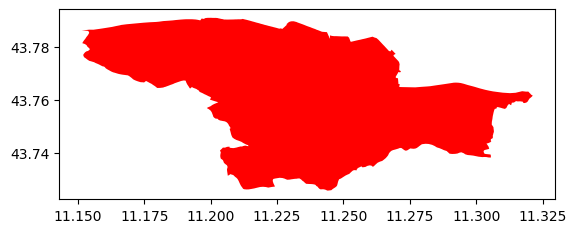

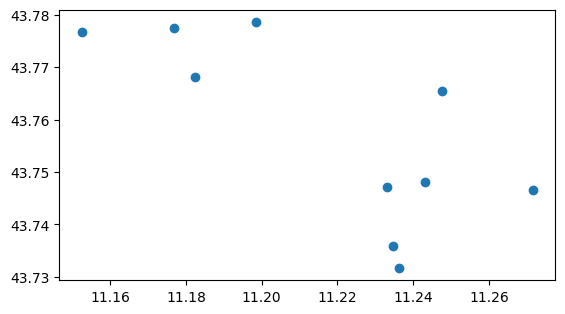

In [22]:

# 3. Scegli una geometria (es: zona trovata prima)
geom = firenze_centro_storico.geometry.iloc[0]
# 5. Genera N punti
N = 10
points = [random_point_in_polygon(geom) for _ in range(N)]

# 6. Crea GeoDataFrame dei punti
points_gdf = gpd.GeoDataFrame(geometry=points, crs=gdf.crs)

# 7. Visualizza
#ax = gdf.plot(color="lightgrey", figsize=(6,6))
gpd.GeoSeries([geom]).plot( color="red")
points_gdf.plot();

In [23]:
print(geom.centroid)

POINT (11.23381369382768 43.76157537950424)


In [24]:
print(geom.representative_point())

POINT (11.256567034557314 43.7582927738754)
